<a href="https://colab.research.google.com/github/ayman-dayf/HuSCF-Comm/blob/main/ReRun_HuSCF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. GPU Check
!nvidia-smi

Sun Sep 13 13:15:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 2. Clone
%cd /content
!git clone https://github.com/youssefga28/HuSCF-GAN.git
%cd /content/HuSCF-GAN
!ls -la

/content
fatal: destination path 'HuSCF-GAN' already exists and is not an empty directory.
/content/HuSCF-GAN
total 100
drwxr-xr-x 7 root root  4096 Sep 13 12:59 .
drwxr-xr-x 1 root root  4096 Sep 13 12:59 ..
-rw-r--r-- 1 root root   826 Sep 13 12:59 configs.yaml
drwxr-xr-x 2 root root  4096 Sep 13 12:59 Cut_Selection
drwxr-xr-x 5 root root  4096 Sep 13 12:59 Data
drwxr-xr-x 8 root root  4096 Sep 13 12:59 .git
-rw-r--r-- 1 root root 16969 Sep 13 12:59 HuSCFGAN.py
drwxr-xr-x 2 root root  4096 Sep 13 12:59 Metrics
-rw-r--r-- 1 root root 16274 Sep 13 12:59 models.py
-rw-r--r-- 1 root root 10414 Sep 13 12:59 README.md
-rw-r--r-- 1 root root   138 Sep 13 12:59 requirements.txt
drwxr-xr-x 8 root root  4096 Sep 13 12:59 Results
-rw-r--r-- 1 root root 13766 Sep 13 12:59 train.py


In [3]:
# 3. Packages
!pip install -q --upgrade pip

!pip install -q \
    torch==2.4.1+cu118 \
    torchvision==0.19.1+cu118 \
    numpy==1.26.4 \
    PyYAML==6.0.2 \
    scikit-learn==1.6.1 \
    matplotlib==3.9.2 \
    scipy==1.14.1 \
    pandas==2.2.3 \
    --extra-index-url https://download.pytorch.org/whl/cu118


ERROR: Could not find a version that satisfies the requirement torch==2.4.1+cu118 (from versions: 2.5.0, 2.5.0+cu118, 2.5.1, 2.5.1+cu118, 2.6.0, 2.6.0+cu118, 2.7.0, 2.7.0+cu118, 2.7.1, 2.7.1+cu118, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0, 2.12.1, 2.13.0, 2.14.0)
ERROR: No matching distribution found for torch==2.4.1+cu118


In [4]:
# 4. Verify PyTorch/GPU
%cd /content/HuSCF-GAN

import torch
import torchvision
import numpy as np

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("NumPy:", np.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


/content/HuSCF-GAN
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
NumPy: 2.1.3
CUDA available: True
GPU: Tesla T4


In [5]:
# 5. Check the configuration

!cat configs.yaml


# Scenario guide:
# - Scenario 1 & 2: IID / non-IID Single-Domain
#     → Only ONE of the num_*_clients should be non-zero
#
# - Scenario 3, 4 & 5: IID / non-IID / Highly non-IID Two-Domain
#     → Exactly TWO of the num_*_clients should be non-zero
#
# - Scenario 6: IID Multi-Domain
#     → ALL num_*_clients should be non-zero (none should be zero)

clients:
  num_digit_clients: 20         #  MNIST
  num_fashion_clients: 20       #  Fashion-MNIST
  num_kmnist_clients: 20       #  Kuzushiji-MNIST
  num_notmnist_clients: 20      #  NotMNIST

training:
  batch_size: 64               # Batch size for local training

experiment:
  scenario: 6                  # Set from 1 to 6 based on experiment type

optimizer:
  learning_rate: 0.0002
  betas:
    - 0.5
    - 0.999

settings:
  local_epochs: 5
  num_rounds: 50


In [6]:
# 6. Import
import torch
import yaml

print("CUDA:", torch.cuda.is_available())

with open("configs.yaml") as f:
    config = yaml.safe_load(f)

print(config)



CUDA: True
{'clients': {'num_digit_clients': 20, 'num_fashion_clients': 20, 'num_kmnist_clients': 20, 'num_notmnist_clients': 20}, 'training': {'batch_size': 64}, 'experiment': {'scenario': 6}, 'optimizer': {'learning_rate': 0.0002, 'betas': [0.5, 0.999]}, 'settings': {'local_epochs': 5, 'num_rounds': 50}}


In [7]:
from models import get_models
from Data import data

print("Imports successful.")


Imports successful.


In [10]:
# 8. Small run

%%writefile configs_test.yaml
clients:
  num_digit_clients: 2
  num_fashion_clients: 2
  num_kmnist_clients: 2
  num_notmnist_clients: 2

training:
  batch_size: 64

experiment:
  scenario: 6

optimizer:
  learning_rate: 0.0002
  betas:
    - 0.5
    - 0.999

settings:
  local_epochs: 1
  num_rounds: 1

!cp configs.yaml configs_original.yaml

!cp configs_test.yaml configs.yaml

#!python train.py


Overwriting configs_test.yaml


In [11]:
!cat configs_test.yaml

clients:
  num_digit_clients: 2
  num_fashion_clients: 2
  num_kmnist_clients: 2
  num_notmnist_clients: 2

training:
  batch_size: 64

experiment:
  scenario: 6

optimizer:
  learning_rate: 0.0002
  betas:
    - 0.5
    - 0.999

settings:
  local_epochs: 1
  num_rounds: 1

!cp configs.yaml configs_original.yaml

!cp configs_test.yaml configs.yaml
!cat configs_test.yaml
#!python train.py


In [12]:
!python train.py


Generation 1/1000 , Latency=7.584172186666667 s
Generation 2/1000 , Latency=7.102474375258074 s
Generation 3/1000 , Latency=7.102474375258074 s
Generation 4/1000 , Latency=7.082883104761905 s
Generation 5/1000 , Latency=7.053489343238096 s
Generation 6/1000 , Latency=7.035797663639029 s
Generation 7/1000 , Latency=7.002459307829504 s
Generation 8/1000 , Latency=7.002459307829504 s
Generation 9/1000 , Latency=7.002459307829504 s
Generation 10/1000 , Latency=7.002459307829504 s
Generation 11/1000 , Latency=7.002459307829504 s
Generation 12/1000 , Latency=7.002459307829504 s
Generation 13/1000 , Latency=7.002459307829504 s
Generation 14/1000 , Latency=7.002459307829504 s
Generation 15/1000 , Latency=7.002459307829504 s
Generation 16/1000 , Latency=7.002459307829504 s
Generation 17/1000 , Latency=7.002459307829504 s
Generation 18/1000 , Latency=7.002459307829504 s
Generation 19/1000 , Latency=7.002459307829504 s
Generation 20/1000 , Latency=7.002459307829504 s
Generation 21/1000 , Latency=

In [13]:
!find Results -type f


Results/Scenario_3/plots/mnist_scores.png
Results/Scenario_3/plots/fmnist_scores.png
Results/Scenario_3/tables/latency.csv
Results/Scenario_3/tables/final_metrics.csv
Results/Scenario_4/plots/mnist_scores.png
Results/Scenario_4/plots/fmnist_scores.png
Results/Scenario_4/tables/latency.csv
Results/Scenario_4/tables/final_metrics.csv
Results/README.md
Results/Scenario_2/plots/mnist_scores.png
Results/Scenario_2/tables/latency.csv
Results/Scenario_2/tables/final_metrics.csv
Results/Scenario_6/plots/mnist_scores.png
Results/Scenario_6/plots/fmnist_scores.png
Results/Scenario_6/plots/kmnist_scores.png
Results/Scenario_6/plots/notmnist_scores.png
Results/Scenario_6/tables/latency.csv
Results/Scenario_6/tables/final_metrics.csv
Results/Scenario_5/plots/mnist_scores.png
Results/Scenario_5/plots/fmnist_scores.png
Results/Scenario_5/tables/latency.csv
Results/Scenario_5/tables/final_metrics.csv
Results/Scenario_1/plots/mnist_scores.png
Results/Scenario_1/tables/latency.csv
Results/Scenario_1/tab


Scenario_1

mnist_scores.png


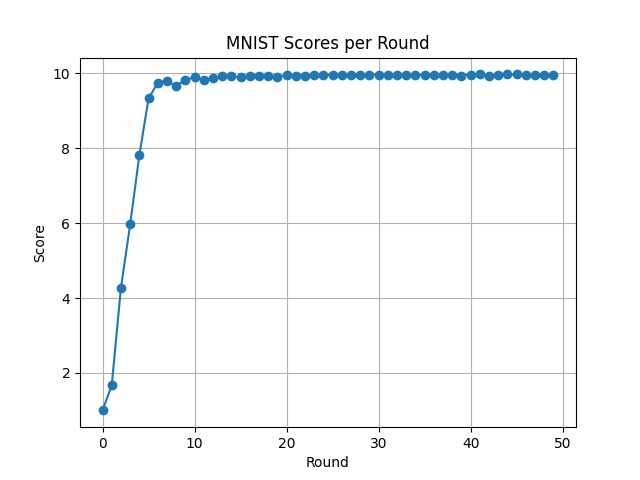


Scenario_2

mnist_scores.png


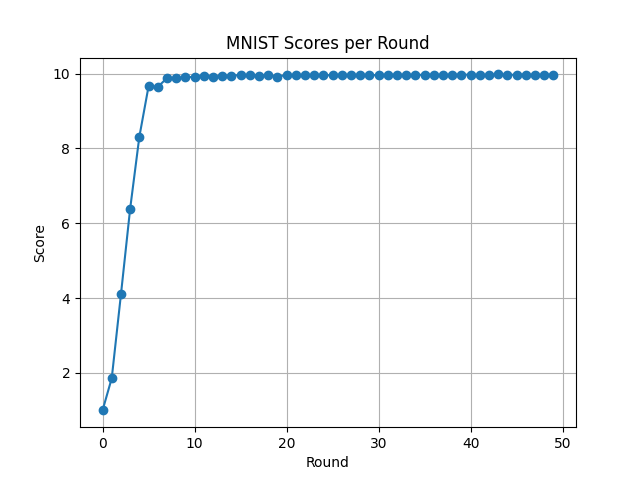


Scenario_3

fmnist_scores.png


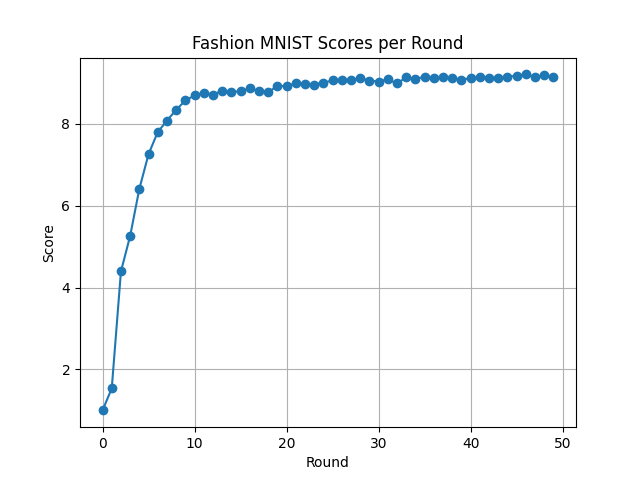


mnist_scores.png


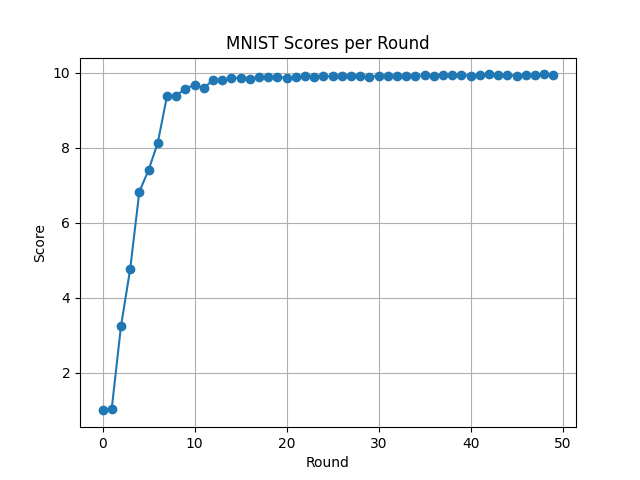


Scenario_4

fmnist_scores.png


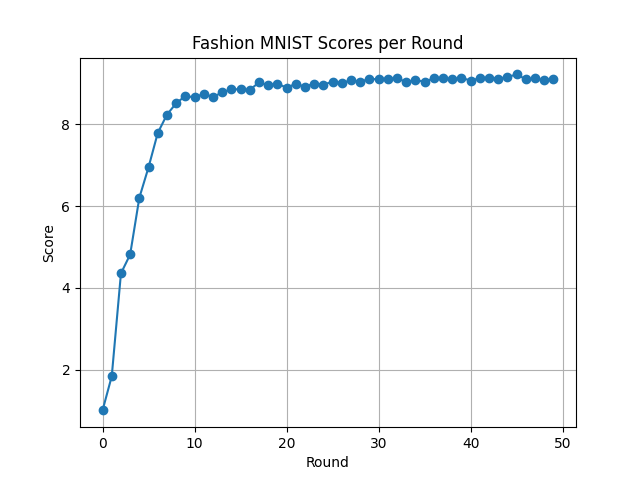


mnist_scores.png


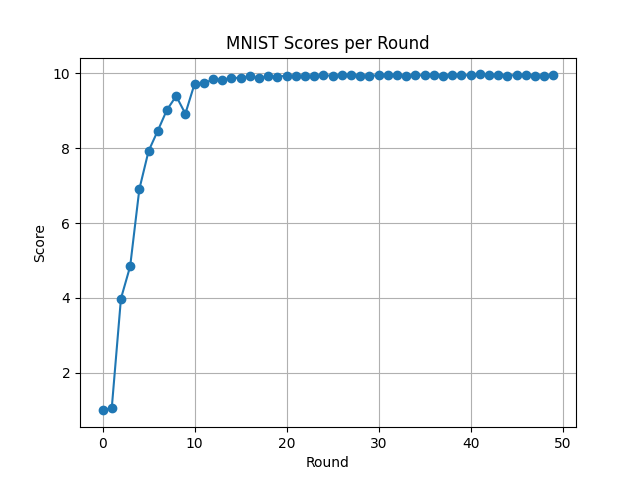


Scenario_5

fmnist_scores.png


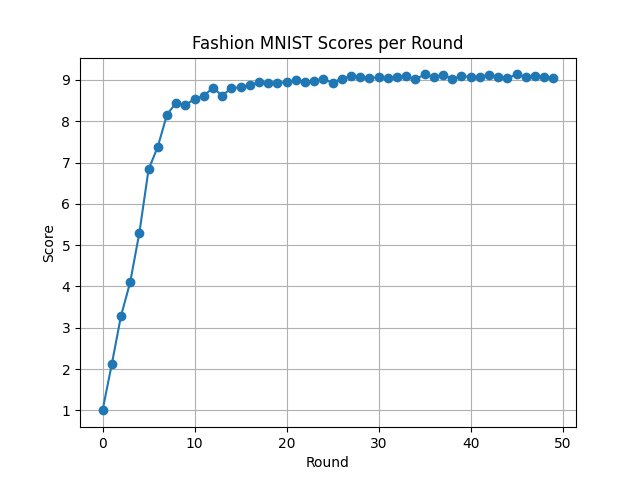


mnist_scores.png


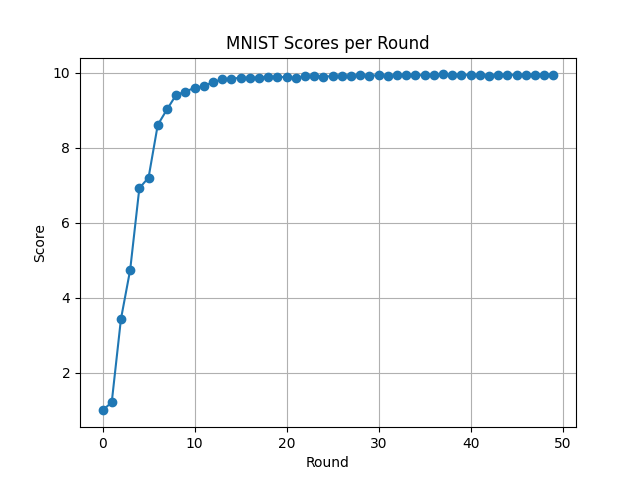


Scenario_6

fmnist_scores.png


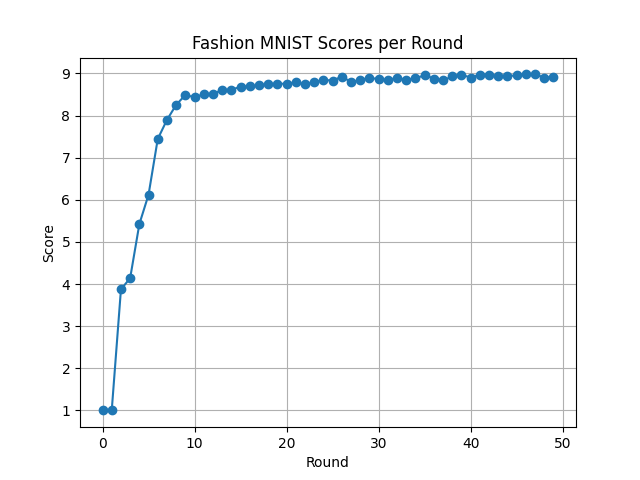


kmnist_scores.png


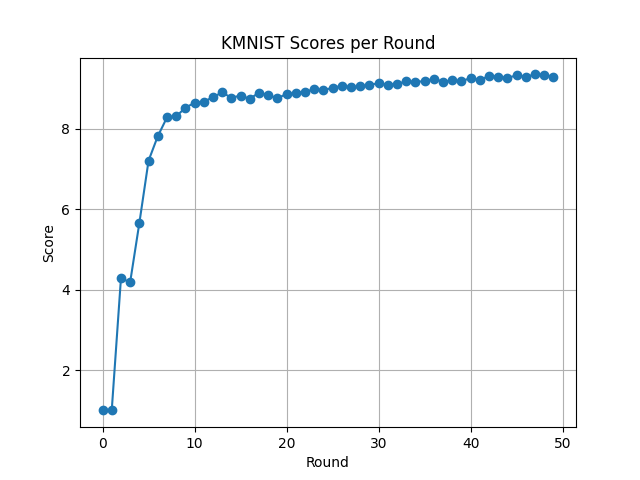


mnist_scores.png


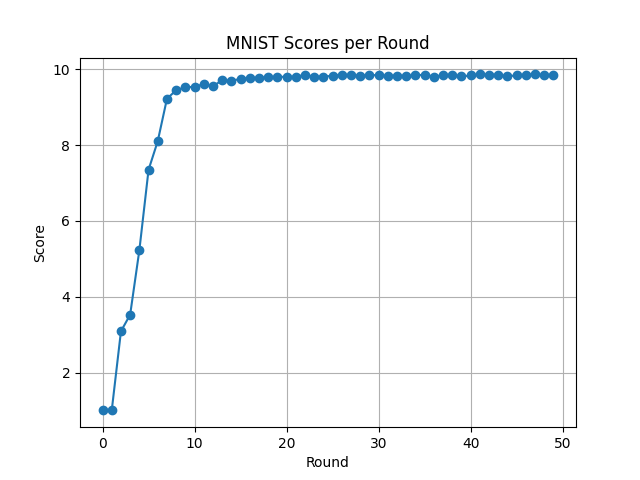


notmnist_scores.png


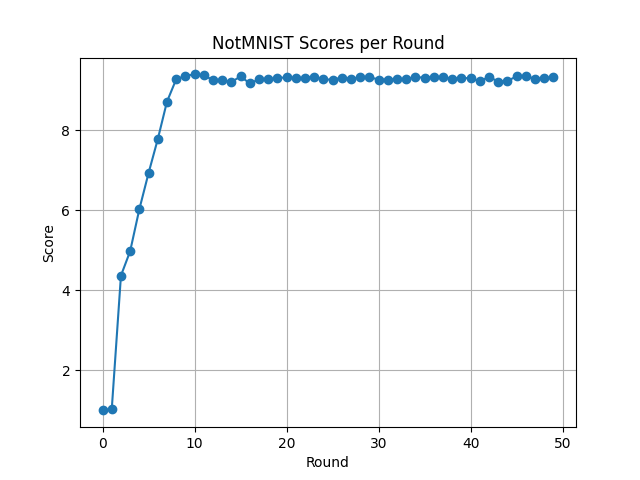

In [14]:
import os
from IPython.display import display, Image

results_dir = "Results"

for scenario in sorted(os.listdir(results_dir)):
    scenario_path = os.path.join(results_dir, scenario)

    if not os.path.isdir(scenario_path) or not scenario.startswith("Scenario_"):
        continue

    plots_dir = os.path.join(scenario_path, "plots")

    if os.path.exists(plots_dir):
        print(f"\n{'='*60}")
        print(f"{scenario}")
        print(f"{'='*60}")

        for filename in sorted(os.listdir(plots_dir)):
            if filename.endswith(".png"):
                filepath = os.path.join(plots_dir, filename)
                print(f"\n{filename}")
                display(Image(filename=filepath))
